# Digital Activation Analysis

For each model, for each occupancy state n, the framework (Box 1) predicts the conditional
steady-state RasGTP:

$$\langle T^* \rangle_n = \frac{n \cdot k_{\text{cat1}} \cdot (R_T - n)}{k_{\text{cat2}} + n \cdot k_{\text{cat1}}}$$

This notebook:
1. Computes predicted peak positions ⟨T*⟩ₙ for each n
2. Loads trajectory from the pkl file
3. Generates 4-panel figure (A: dual time course, B: SS-color scatter, C: SOS occupancy, D: quantized histogram)
4. Compares simulation peak modes to theory
5. Validates conditional steady state using peak modes from the SSA trajectory


In [13]:
import pickle
import bionetgen
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D


## Model Configuration Set Up

In [14]:

MODEL   = "Model1"   # "Model1", "Model2", "Model3"

PARAMS = {
    "Model1": dict(Kcat1=1e-2, Kcat2=2.5e-3, RhoSOS=10,  n_bound_list=list(range(5))),
    "Model2": dict(Kcat1=1e-2, Kcat2=2.5e-2, RhoSOS=30,  n_bound_list=list(range(8))),
    "Model3": dict(Kcat1=1e-2, Kcat2=2.5e-3, RhoSOS=10,  n_bound_list=list(range(5))),
}

p            = PARAMS[MODEL]
Kcat1        = p['Kcat1']
Kcat2        = p['Kcat2']
RhoSOS       = p['RhoSOS']
n_bound_list = p['n_bound_list']
RasTotal     = 1000
#ss_tolerance = 25    # +/- window for quantization ranges (RasGTP count), alterative g


##  Predicted peak positions

Equation from Box 1
$$\langle T^* \rangle_n = \frac{n \cdot k_{\text{cat1}} \cdot (R_T - n)}{k_{\text{cat2}} + n \cdot k_{\text{cat1}}}$$

The (RT - n) factor accounts for n Ras molecules sequestered in SOS:Ras complexes.


The increment between adjacent peaks (⟨T*⟩ₙ - ⟨T*⟩ₙ₋₁) shrinks with increasing n, this is why Model 1 looks bimodal (large n=0→1 gap, small gaps after).


In [15]:
def predicted_ss(n, Kcat1, Kcat2, RasTotal):
    """Conditional steady-state RasGTP for n bound SOS molecules."""
    if n == 0:
        return 0.0
    return (RasTotal - n) * (n * Kcat1) / (n * Kcat1 + Kcat2)

R_ss_array = np.array([predicted_ss(n, Kcat1, Kcat2, RasTotal) for n in n_bound_list])

print(f"{'n_bound':<10} {'Predicted ⟨T*⟩_n':<20} {'Δ from n-1'}")
print("-" * 45)
for i, (n, ss) in enumerate(zip(n_bound_list, R_ss_array)):
    delta = ss - R_ss_array[i-1] if i > 0 else "—"
    delta_str = f"{delta:.1f}" if isinstance(delta, float) else delta
    print(f"{n:<10} {ss:<20.1f} {delta_str}")


n_bound    Predicted ⟨T*⟩_n     Δ from n-1
---------------------------------------------
0          0.0                  —
1          799.2                799.2
2          887.1                87.9
3          920.3                33.2
4          937.4                17.1


## Load simulation trajectory

In [16]:

with open(MODEL + '_traj.pkl', 'rb') as f:
    pl = pickle.load(f)

idx = pl['pval'].index(RhoSOS)
t   = pl['traj'][idx]

time_vals     = t['time']
ras_vals      = np.asarray(t['totalRasGTP'])
boundras_vals = np.asarray(t['totalBoundRas']).astype(int)

print(f"Loaded {MODEL} at [SOS]={RhoSOS} nM")
print(f"Time range: {time_vals[0]:.0f} — {time_vals[-1]:.0f} s  ({len(time_vals)} pts)")
print(f"RasGTP range: {ras_vals.min():.0f} — {ras_vals.max():.0f}")


Loaded Model1 at [SOS]=10 nM
Time range: 0 — 100000 s  (10000 pts)
RasGTP range: 0 — 969


##  Quantization ranges 

Each occupancy state n produces a peak at ⟨T*⟩ₙ. To quantify how much of thetrajectory falls near each predicted peak, we define a window around each ⟨T*⟩ₙ. 


**How window widths are set:**

The theoretical width of each peak is the binomial standard deviation:
  σₙ = √(RT · pₙ · (1 - pₙ))   where pₙ = n·kcat1 / (n·kcat1 + kcat2)

We use ±2σₙ as the window half-width. Windows are  capped at midpoints between adjacent ⟨T*⟩ₙ values so they never overlap.

Under perfect timescale separation, ±2σₙ captures ~95% of each peak.
The window widths will automatically be wider for intermediate pₙ (near 0.5) and narrower near saturation.

In [17]:
def sigma(n, Kcat1, Kcat2, RasTotal):
    """Theoretical peak width"""    
    if n == 0:
        return 0.0
    pn = n * Kcat1 / (n * Kcat1 + Kcat2)
    return np.sqrt(RasTotal * pn * (1 - pn))

def build_theory_windows(ss_array, n_bound_list, Kcat1, Kcat2, RasTotal, n_sigma=2):
    """
    Windows of +/- n_sigma·σₙ around each predicted peak, capped at midpoints
    between neighbors so windows never overlap.
    """
    sigmas = [sigma(n, Kcat1, Kcat2, RasTotal) for n in n_bound_list]
    ranges = []
    for i, (ss, sig) in enumerate(zip(ss_array, sigmas)):

        if n == 0:
            half = 20
        else:
            half = 2 * sig
    
        lo = ss - half
        hi = ss + half
        if i > 0:
            lo = max(lo, (ss_array[i-1] + ss) / 2)
        if i < len(ss_array) - 1:
            hi = min(hi, (ss + ss_array[i+1]) / 2)
        lo = max(lo, 0)
        hi = min(hi, RasTotal)
        ranges.append((lo, hi))
    return ranges, sigmas

quantized_ranges, sigmas = build_theory_windows(
    R_ss_array, n_bound_list, Kcat1, Kcat2, RasTotal, n_sigma=2
)

print(f"{'n':<6} {'⟨T*⟩ₙ':<10} {'σₙ':<8} {'window':<26} {'width'}")
print("-" * 58)
for n, ss, sig, (lo, hi) in zip(n_bound_list, R_ss_array, sigmas, quantized_ranges):
    print(f"{n:<6} {ss:<10.1f} {sig:<8.1f} [{lo:<6.1f}, {hi:<6.1f}]   {hi-lo:.1f}")


n      ⟨T*⟩ₙ      σₙ       window                     width
----------------------------------------------------------
0      0.0        0.0      [0.0   , 0.0   ]   0.0
1      799.2      12.6     [773.9 , 824.5 ]   50.6
2      887.1      9.9      [867.2 , 903.7 ]   36.5
3      920.3      8.4      [903.7 , 928.9 ]   25.2
4      937.4      7.4      [928.9 , 952.3 ]   23.4


In [18]:
def assign_dot_colors(ras_vals, quantized_ranges, colors):
    grey = np.array([0.82, 0.82, 0.82, 1.0])
    result = np.tile(grey, (len(ras_vals), 1)).astype(float)
    for i, (lo, hi) in enumerate(quantized_ranges):
        mask = (ras_vals >= lo) & (ras_vals <= hi)
        result[mask] = colors[i]
    return result

def quantize_histogram(counts_norm, bin_centers, q_ranges, n_bound_list, ss_array):
    """
    Fraction of histogram within each theory window.
    """
    total = counts_norm.sum()
    stats = []
    for i, (lo, hi) in enumerate(q_ranges):
        idx_in = np.where((bin_centers >= lo) & (bin_centers <= hi))[0]
        cnt = counts_norm[idx_in].sum() if idx_in.size > 0 else 0.0
        stats.append({
            'n_bound': n_bound_list[i],
            'ss_val':  ss_array[i],
            'lo': lo, 'hi': hi,
            'pct': 100 * cnt / total if total > 0 else 0.0
        })
    return stats

# histogram for table and figures 
n_bins = 80
counts, edges = np.histogram(ras_vals, bins=n_bins, range=(0, RasTotal))
counts_norm   = counts / counts.max()
bin_centers   = 0.5 * (edges[:-1] + edges[1:])
bin_width     = np.diff(edges)

colors        = plt.cm.viridis(np.linspace(0, 1, len(n_bound_list)))
dot_colors = assign_dot_colors(ras_vals, quantized_ranges, colors)

#dot_colors    = assign_dot_colors(ras_vals, R_ss_array, quantized_ranges, colors)
range_stats   = quantize_histogram(counts_norm, bin_centers, quantized_ranges,
                                   n_bound_list, R_ss_array)
pct_quantized = sum(s['pct'] for s in range_stats)


## 4-panel figure — Panels A, B, C, D



-  **A** Dual time course: RasGTP (top) and Bound SOS (bottom)
- **B** Time course scatter, each point colored by which quantization window it falls in;
  dashed lines mark predicted ⟨T*⟩ₙ positions
- **C** Bound SOS occupancy histogram
- **D** RasGTP histogram with colored spans marking theory windows and dashed ⟨T*⟩ₙ lines

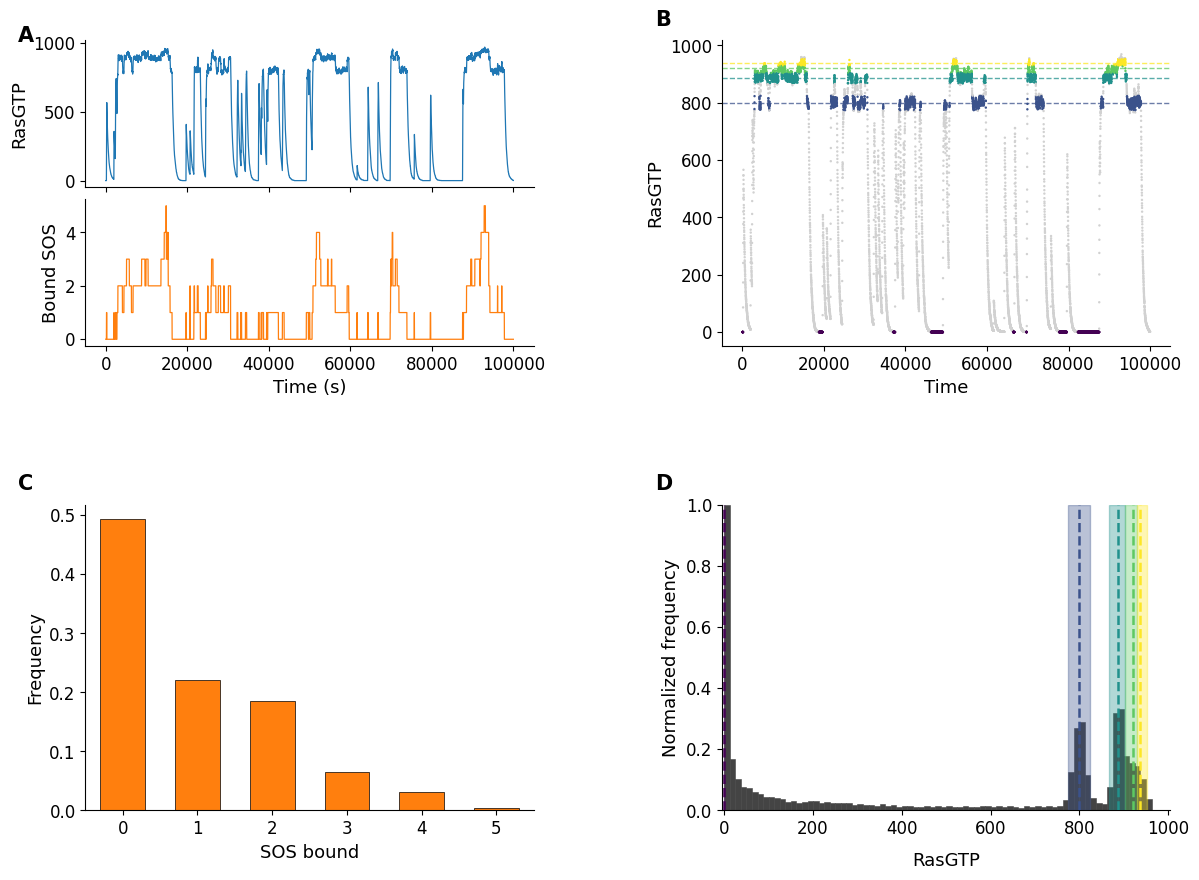

In [19]:
LABEL_SIZE = 12
AXIS_SIZE  = 13
PANEL_SIZE = 15
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_ras   = color_cycle[0]
color_bras  = color_cycle[1]

fig = plt.figure(figsize=(14, 10))
outer = gridspec.GridSpec(2, 2, figure=fig, wspace=0.42, hspace=0.52)

innerA = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, 0],
                                          hspace=0.08, height_ratios=[1, 1])
ax_A_top = fig.add_subplot(innerA[0])
ax_A_bot = fig.add_subplot(innerA[1], sharex=ax_A_top)
ax_B = fig.add_subplot(outer[0, 1])
ax_C = fig.add_subplot(outer[1, 0])
ax_D = fig.add_subplot(outer[1, 1])

viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(n_bound_list)))

for letter, ax in zip(['A','B','C','D'], [ax_A_top, ax_B, ax_C, ax_D]):
    ax.text(-0.15, 1.10, letter, transform=ax.transAxes,
            fontsize=PANEL_SIZE, fontweight='bold', va='top', ha='left')

# ── Panel A — Dual time course ──────────────────────────────────


ax_A_top.plot(time_vals, ras_vals,      color=color_ras,  lw=0.9)
ax_A_bot.plot(time_vals, boundras_vals, color=color_bras, lw=0.9)
ax_A_top.set_ylabel('RasGTP',    fontsize=AXIS_SIZE)
ax_A_bot.set_ylabel('Bound SOS', fontsize=AXIS_SIZE)
ax_A_bot.set_xlabel('Time (s)',  fontsize=AXIS_SIZE)
plt.setp(ax_A_top.get_xticklabels(), visible=False)
for ax in (ax_A_top, ax_A_bot):
    ax.tick_params(labelsize=LABEL_SIZE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Panel B — Scatter colored by quantization window/steadystate ────────────
 
ax_B.scatter(time_vals, ras_vals, c=dot_colors, s=3, linewidths=0, rasterized=True)



for ss, color in zip(R_ss_array, viridis_colors):
    if ss > 0:
        ax_B.axhline(ss, color=color, lw=1.0, ls='--', alpha=0.75)

ax_B.set_xlabel('Time',   fontsize=AXIS_SIZE)
ax_B.set_ylabel('RasGTP', fontsize=AXIS_SIZE)
ax_B.tick_params(labelsize=LABEL_SIZE)
ax_B.spines['top'].set_visible(False)
ax_B.spines['right'].set_visible(False)

# ── Panel C — Bound SOS histogram ────────────────────────────────
max_bound = int(boundras_vals.max()) if boundras_vals.size else 8
sos_bar_width = 0.6
sos_bins = np.arange(max_bound + 2) - 0.5 * sos_bar_width
ax_C.hist(boundras_vals, bins=sos_bins, density=True, align='mid',
          width=sos_bar_width, color=color_bras, edgecolor='black', linewidth=0.5)
ax_C.set_xlim(-0.5, max_bound + 0.5)
ax_C.set_xticks(np.arange(0, max_bound + 1))
ax_C.set_xticklabels([str(i) for i in range(max_bound + 1)])
ax_C.set_xlabel('SOS bound',  fontsize=AXIS_SIZE)
ax_C.set_ylabel('Frequency',  fontsize=AXIS_SIZE)
ax_C.tick_params(labelsize=LABEL_SIZE)
ax_C.spines['top'].set_visible(False)
ax_C.spines['right'].set_visible(False)

# ── Panel D — Quantized RasGTP histogram ─────────────────────────
ax_D.bar(bin_centers, counts_norm, width=bin_width,
         color='#444444', edgecolor='#444444', linewidth=0.4, alpha=1.0, zorder=2)
ax_D.set_ylim(0, 1.0)
ax_D.set_xlim(-5, RasTotal + 5)
for s, color in zip(range_stats, colors):
    ax_D.axvspan(s['lo'], s['hi'], alpha=0.35, color=color, zorder=3)
    ax_D.axvline(s['ss_val'], color=color, lw=1.8, ls='--', zorder=4)
ax_D.set_xlabel('RasGTP', fontsize=AXIS_SIZE, labelpad=10)
ax_D.set_ylabel('Normalized frequency', fontsize=AXIS_SIZE)
ax_D.tick_params(labelsize=LABEL_SIZE)
ax_D.spines['top'].set_visible(False)
ax_D.spines['right'].set_visible(False)


plt.show()


In [20]:
print(f"{'n':<6} {'⟨T*⟩ₙ':<10} {'σₙ':<8} {'window':<26} {'%  in window'}")
print("-" * 62)
for s, sig in zip(range_stats, sigmas):
    print(f"{s['n_bound']:<6} {s['ss_val']:<10.1f} {sig:<8.1f} "          f"[{s['lo']:<6.1f}, {s['hi']:<6.1f}]   {s['pct']:.1f}%")
print(f"\nTotal in quantized windows : {pct_quantized:.1f}%")
print(f"Total outside all windows  : {100 - pct_quantized:.1f}%")


n      ⟨T*⟩ₙ      σₙ       window                     %  in window
--------------------------------------------------------------
0      0.0        0.0      [0.0   , 0.0   ]   0.0%
1      799.2      12.6     [773.9 , 824.5 ]   16.6%
2      887.1      9.9      [867.2 , 903.7 ]   15.1%
3      920.3      8.4      [903.7 , 928.9 ]   6.9%
4      937.4      7.4      [928.9 , 952.3 ]   5.1%

Total in quantized windows : 43.8%
Total outside all windows  : 56.2%


In [21]:
state_occupancy = []

for (lo, hi) in quantized_ranges:
    mask = (ras_vals >= lo) & (ras_vals < hi)
    frac = np.sum(mask) / len(ras_vals)
    state_occupancy.append(frac)


for i, frac in enumerate(state_occupancy):
    print(f"n={n_bound_list[i]} -> {frac*100:.2f}%")

n=0 -> 0.00%
n=1 -> 16.73%
n=2 -> 16.22%
n=3 -> 6.69%
n=4 -> 4.33%


## Peak mode vs predicted ⟨T*⟩ₙ

For each occupancy state n, we condition the SSA trajectory on that n
(using `boundras_vals == n`), find the mode of the resulting RasGTP histogram,
and compare to the analytical prediction.

n=0  mode=8.3  pred=0
n=1  mode=808.3  pred=799.2  err=1.1%
n=2  mode=891.7  pred=887.1  err=0.5%
n=3  mode=925.0  pred=920.3  err=0.5%
n=4  mode=941.7  pred=937.4  err=0.5%


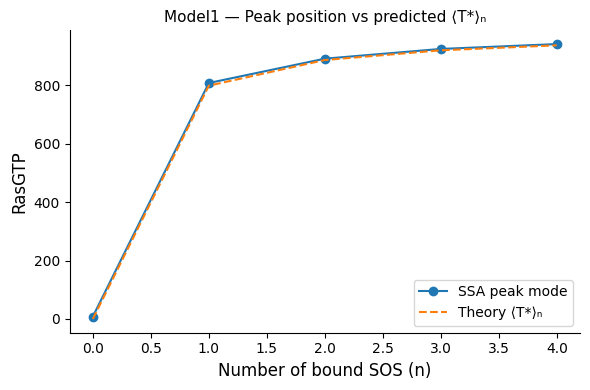

In [22]:


with open(MODEL + '_traj.pkl', 'rb') as f:
    pl = pickle.load(f)

idx = pl['pval'].index(RhoSOS)
t   = pl['traj'][idx]
ras_vals      = np.asarray(t['totalRasGTP'])
boundras_vals = np.asarray(t['totalBoundRas']).astype(int)

n_store      = []
sim_mode_store  = []
pred_store   = []

for n in n_bound_list:
    mask = boundras_vals == n
    ras_n = ras_vals[mask]

    if ras_n.size < 20:
        continue

    # mode = center of peak bin in the conditional histogram
    counts, edges = np.histogram(ras_n, bins=60, range=(0, RasTotal))
    sim_mode = 0.5 * (edges[np.argmax(counts)] + edges[np.argmax(counts) + 1])

    pred = (RasTotal - n) * (n * Kcat1) / (n * Kcat1 + Kcat2) if n > 0 else 0

    n_store.append(n)
    sim_mode_store.append(sim_mode)
    pred_store.append(pred)

    print(f"n={n}  mode={sim_mode:.1f}  pred={pred:.1f}  err={abs(sim_mode-pred)/pred*100:.1f}%" if pred > 0 else f"n={n}  mode={sim_mode:.1f}  pred=0")

# plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(n_store, sim_mode_store, 'o-', label='SSA peak mode')
ax.plot(n_store, pred_store, '--', label='Theory ⟨T*⟩ₙ')
ax.set_xlabel('Number of bound SOS (n)', fontsize=12)
ax.set_ylabel('RasGTP', fontsize=12)
ax.set_title(f'{MODEL} — Peak position vs predicted ⟨T*⟩ₙ', fontsize=11)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

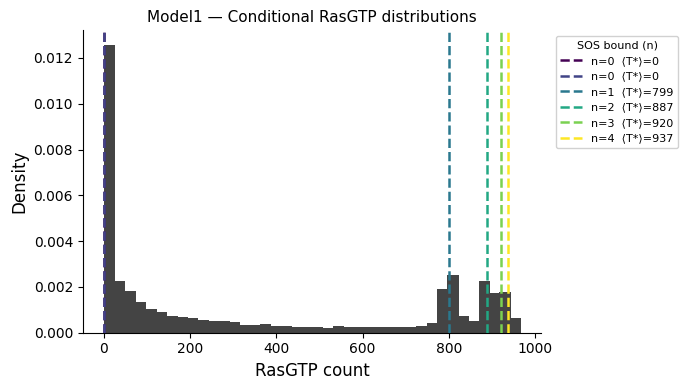

In [23]:

STOCH_MODEL  = MODEL 
T_END_SSA    = 100000
N_STEPS_SSA  = 10000
N_BOUND_LIST = [0] + n_bound_list

colors = plt.cm.viridis(np.linspace(0, 1, len(N_BOUND_LIST)))

fig, ax = plt.subplots(figsize=(7, 4))

for idx, n in enumerate(N_BOUND_LIST):
    model = bionetgen.bngmodel(STOCH_MODEL + ".bngl")
    sim   = model.setup_simulator()
    sim.setIntegrator('gillespie')
    sim.RasTotal        = RasTotal - n
    sim.initialBoundSOS = n
    sim.RhoSOS          = RhoSOS #this is going to be what is in .bngl 
    sim.reset()
    sim.selections = ['time', 'totalRasGTP']
    traj = sim.simulate(0, T_END_SSA, N_STEPS_SSA)
    ras  = traj[:, 1]

    pred = (RasTotal - n) * (n * Kcat1) / (n * Kcat1 + Kcat2) if n > 0 else 0

    ax.hist(ras, bins=40, density=True, alpha=0.85,
            color='#444444', edgecolor='#444444', linewidth=0.4, zorder=2)
    ax.axvline(pred, color=colors[idx], lw=1.8, ls='--', zorder=3,
               label=f'n={n}  ⟨T*⟩={pred:.0f}')

ax.set_xlabel('RasGTP count', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'{MODEL} — Conditional RasGTP distributions', fontsize=11)
ax.legend(fontsize=8, title='SOS bound (n)', title_fontsize=8,
          bbox_to_anchor=(1.02, 1), loc='upper left', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Multiple Corrals

Corral  0 | seed= 133259 | min=0.0 max=958.0 final=11.0
Corral  1 | seed=  48807 | min=0.0 max=972.0 final=145.0
Corral  2 | seed=  88133 | min=0.0 max=972.0 final=935.0
Corral  3 | seed= 647696 | min=0.0 max=937.0 final=29.0
Corral  4 | seed=  10742 | min=0.0 max=939.0 final=465.0
Corral  5 | seed= 889123 | min=0.0 max=916.0 final=30.0
Corral  6 | seed= 651744 | min=0.0 max=964.0 final=14.0
Corral  7 | seed= 439039 | min=0.0 max=962.0 final=799.0
Corral  8 | seed= 895762 | min=0.0 max=945.0 final=720.0
Corral  9 | seed= 397628 | min=0.0 max=956.0 final=0.0
Corral 10 | seed= 873598 | min=0.0 max=958.0 final=12.0
Corral 11 | seed= 863178 | min=0.0 max=957.0 final=126.0
Corral 12 | seed= 496856 | min=0.0 max=968.0 final=1.0
Corral 13 | seed= 553403 | min=0.0 max=965.0 final=184.0
Corral 14 | seed= 281432 | min=0.0 max=962.0 final=0.0
Corral 15 | seed= 594925 | min=0.0 max=970.0 final=957.0
Corral 16 | seed=  64741 | min=0.0 max=966.0 final=896.0
Corral 17 | seed= 891478 | min=0.0 max=976

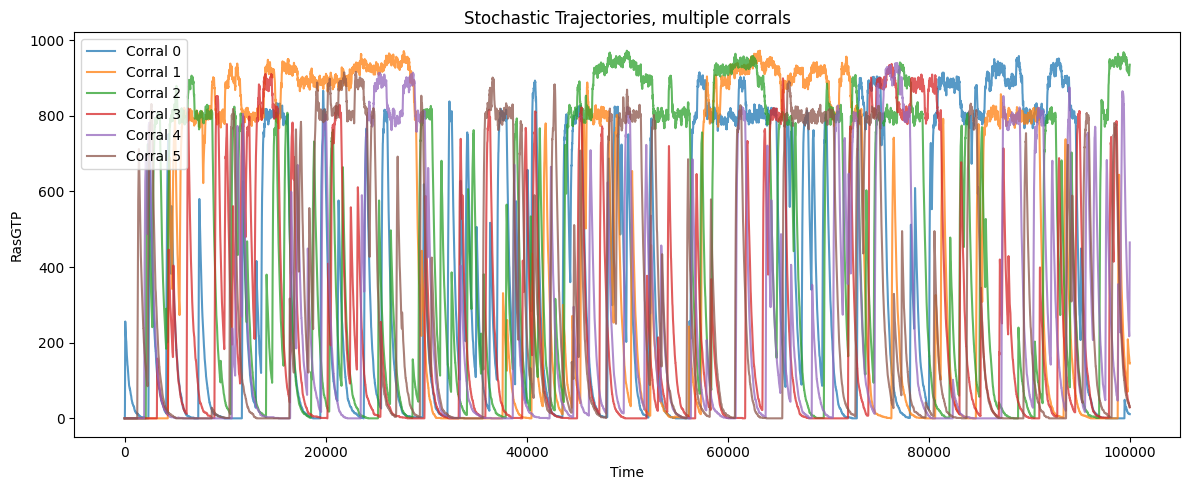

In [24]:
import bionetgen
import numpy as np
import matplotlib.pyplot as plt

MODEL = "Model1" # "Model2"
RasTotal = 1000
RhoSOS = 30
t_end = 100000
n_steps = 10000
n_corrals = 25


timepoints = np.linspace(t_end/3, t_end, 3)
ras_values = np.zeros((3, n_corrals))

# plot just to check 
fig, ax = plt.subplots(figsize=(12, 5))

for i in range(n_corrals):
    model = bionetgen.bngmodel(MODEL + ".bngl")
    sim = model.setup_simulator()
    sim.setIntegrator('gillespie')

    
    seed = np.random.randint(1, 1000000)
    sim.integrator.seed = seed          
    sim.model.setRandomSeed(seed)       

    sim.RhoSOS = RhoSOS          
    sim.selections = ['time', 'totalRasGTP']

    traj = sim.simulate(0, t_end, n_steps)
    time = traj[:, 0]
    ras  = traj[:, 1]

    print(f"Corral {i:2d} | seed={seed:>7d} | "
          f"min={ras.min():.1f} max={ras.max():.1f} final={ras[-1]:.1f}")

    if i < 6:
        ax.plot(time, ras, alpha=0.75, label=f"Corral {i}")

    for j, t in enumerate(timepoints):
        idx = np.argmin(np.abs(time - t))
        ras_values[j, i] = ras[idx]

ax.set_xlabel("Time")
ax.set_ylabel("RasGTP")
ax.set_title("Stochastic Trajectories, multiple corrals")
ax.legend()
plt.tight_layout()
plt.show()



## Bifurcation Analysis 

### 3 panel bifurcation analysis for all 3 models 

Loaded Model1: 3 trajectories, [SOS] = [1, 5, 10] nM


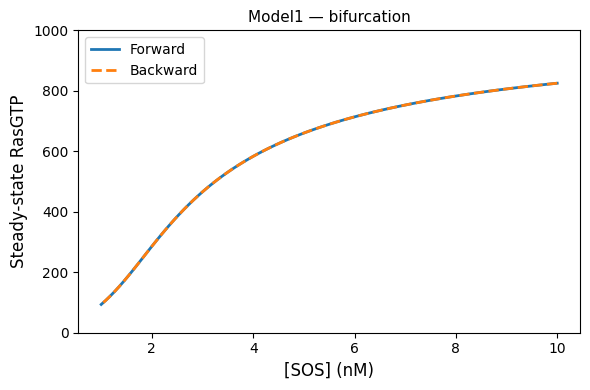

In [25]:
import bionetgen

MODEL = "Model1"   # "Model1", "Model2", "Model3"

with open(MODEL + '_traj.pkl', 'rb') as f:
    pl = pickle.load(f)

pval = pl['pval']
traj = pl['traj']
print(f"Loaded {MODEL}: {len(traj)} trajectories, [SOS] = {pval} nM")

KON_BIF = {'Model1': 7e-8, 'Model2': 7e-8, 'Model3': 7e-5}[MODEL]

model_bif = bionetgen.bngmodel(MODEL + ".bngl")
sim_bif   = model_bif.setup_simulator()
sim_bif.setIntegrator('cvode')
sim_bif.selections = ['totalRasGTP']

sos_range = np.linspace(1, max(pval), 100)
ras_fwd, ras_bwd = [], []

for sos in sos_range:
    sim_bif.RhoSOS = sos; sim_bif.Kon1 = sos * KON_BIF; sim_bif.Kon2 = sos * KON_BIF
    sim_bif.reset()
    ras_fwd.append(sim_bif.simulate(0, 1000000, 2)[-1, 0])

for sos in sos_range[::-1]:
    sim_bif.RhoSOS = sos; sim_bif.Kon1 = sos * KON_BIF; sim_bif.Kon2 = sos * KON_BIF
    sim_bif.reset()
    ras_bwd.append(sim_bif.simulate(0, 1000000, 2)[-1, 0])

plt.figure(figsize=(6, 4))
plt.plot(sos_range, ras_fwd, label='Forward', lw=2)
plt.plot(sos_range[::-1], ras_bwd, label='Backward', lw=2, ls='--')
plt.xlabel('[SOS] (nM)', fontsize=12)
plt.ylabel('Steady-state RasGTP', fontsize=12)
plt.title(f'{MODEL} — bifurcation', fontsize=11)
plt.ylim(0, 1000)
plt.legend()
plt.tight_layout()

plt.show()


Model1 done.
Model2 done.
Model3 done.


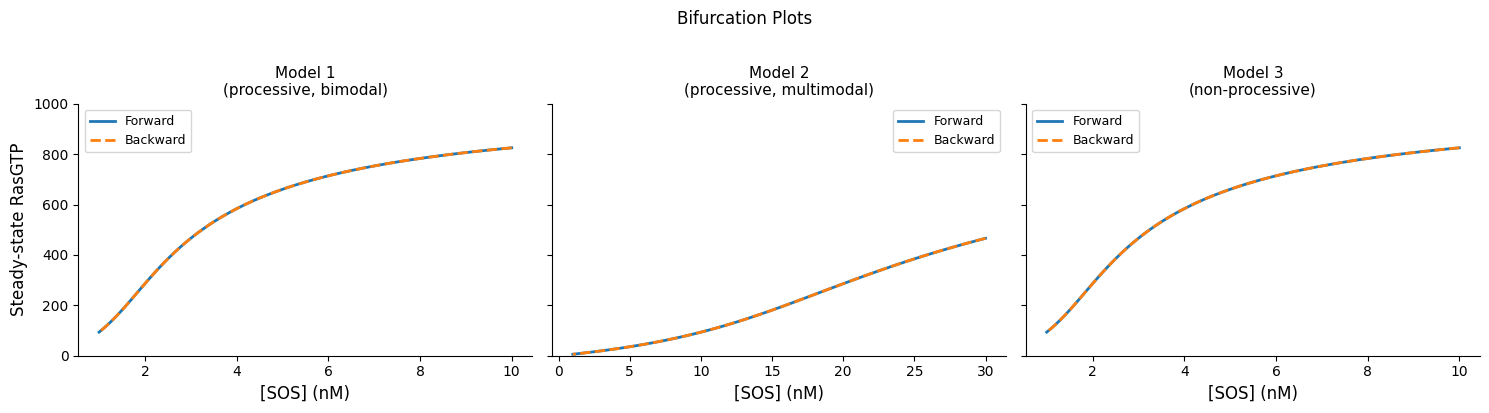

In [26]:
import bionetgen
import numpy as np
import matplotlib.pyplot as plt

MODELS = ["Model1", "Model2", "Model3"]

PARAMS = {
    'Model1': {
        'kon': 7e-8,
        'koff1': 5e-3,
        'koff2': 5e-4,
        'sos_max': 10,
        'title': 'Model 1\n(processive, bimodal)',
    },
    'Model2': {
        'kon': 7e-8,
        'koff1': 5e-3,
        'koff2': 5e-4,
        'sos_max': 30,
        'title': 'Model 2\n(processive, multimodal)',
    },
    'Model3': {
        'kon': 7e-5,
        'koff1': 5,
        'koff2': 0.5,
        'sos_max': 10,
        'title': 'Model 3\n(non-processive)',
    }
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, MODEL in zip(axes, MODELS):

    p = PARAMS[MODEL]

    sos_range = np.linspace(1, p['sos_max'], 100)

    model_bif = bionetgen.bngmodel(MODEL + ".bngl")
    sim_bif   = model_bif.setup_simulator()

    sim_bif.setIntegrator('cvode')
    sim_bif.selections = ['totalRasGTP']

    ras_fwd = []
    ras_bwd = []

    # ---------------- FORWARD SCAN ----------------
    sim_bif.reset()

    for sos in sos_range:

        sim_bif.RhoSOS = sos

        sim_bif.Kon1  = sos * p['kon']
        sim_bif.Kon2  = sos * p['kon']

        sim_bif.Koff1 = p['koff1']
        sim_bif.Koff2 = p['koff2']

        out = sim_bif.simulate(0, 1000000, 2)

        ras_fwd.append(out[-1, 0])

    # ---------------- BACKWARD SCAN ----------------
    sim_bif.reset()

    for sos in sos_range[::-1]:

        sim_bif.RhoSOS = sos

        sim_bif.Kon1  = sos * p['kon']
        sim_bif.Kon2  = sos * p['kon']

        sim_bif.Koff1 = p['koff1']
        sim_bif.Koff2 = p['koff2']

        out = sim_bif.simulate(0, 1000000, 2)

        ras_bwd.append(out[-1, 0])

    # plotting
    ax.plot(
        sos_range,
        ras_fwd,
        lw=2,
        label='Forward'
    )

    ax.plot(
        sos_range[::-1],
        ras_bwd,
        lw=2,
        ls='--',
        label='Backward'
    )

    ax.set_xlabel('[SOS] (nM)', fontsize=12)
    ax.set_title(p['title'], fontsize=11)

    ax.set_ylim(0, 1000)

    ax.legend(fontsize=9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.tick_params(labelsize=10)

    print(f"{MODEL} done.")

axes[0].set_ylabel('Steady-state RasGTP', fontsize=12)

fig.suptitle(
    'Bifurcation Plots',
    fontsize=12,
    y=1.02
)

plt.tight_layout()
plt.show()